Processing training images for: Moeez
Processing training images for: Musaab
Processing training images for: jibran
Training for 2000 epochs. Please wait...
Epoch 0, Loss: 1.7235
Epoch 500, Loss: 0.0003
Epoch 1000, Loss: 0.0002
Epoch 1500, Loss: 0.0001

Training Complete!


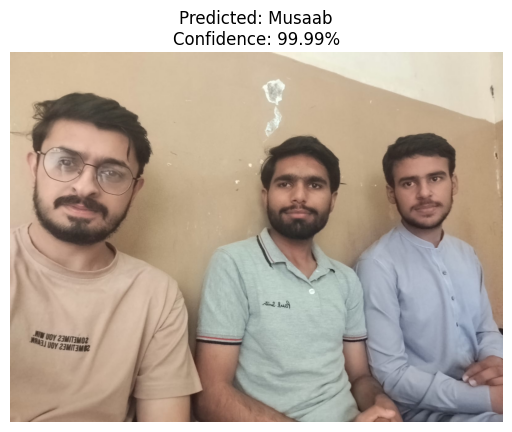

In [6]:
import os
import numpy as np
from PIL import Image
import random
import matplotlib.pyplot as plt

class MLPFaceRecognizer:
    def __init__(self, size=(100, 100), hidden_size=256, learning_rate=0.01, epochs=1500):
        self.size = size
        self.input_size = size[0] * size[1] * 3
        self.hidden_size = hidden_size
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.names = {}
        self.W1, self.b1 = None, None
        self.W2, self.b2 = None, None

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

    def softmax(self, x):
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

    def preprocess_image(self, img_path):
        """Loads, Center Crops, and Normalizes image."""
        img = Image.open(img_path).convert('RGB')

        # 1. Center Crop (To remove background noise)
        width, height = img.size
        new_edge = min(width, height)
        left = (width - new_edge)/2
        top = (height - new_edge)/2
        right = (width + new_edge)/2
        bottom = (height + new_edge)/2
        img = img.crop((left, top, right, bottom))

        # 2. Resize and Flatten
        img = img.resize(self.size, Image.Resampling.LANCZOS)
        img_array = np.array(img).flatten() / 255.0

        # 3. Simple Standardization
        return (img_array - np.mean(img_array)) / (np.std(img_array) + 1e-8)

    def train(self, root_folder):
        if not os.path.exists(root_folder):
            print(f"Path not found: {root_folder}")
            return

        X, y_labels = [], []
        temp_names = []

        # Load folders
        folders = sorted([f for f in os.listdir(root_folder) if os.path.isdir(os.path.join(root_folder, f)) and f.lower() != "test"])

        for label_idx, person_name in enumerate(folders):
            person_path = os.path.join(root_folder, person_name)
            self.names[label_idx] = person_name
            print(f"Processing training images for: {person_name}")

            for filename in os.listdir(person_path):
                if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                    X.append(self.preprocess_image(os.path.join(person_path, filename)))
                    y_labels.append(label_idx)

        X = np.array(X)
        num_classes = len(self.names)
        Y = np.eye(num_classes)[y_labels]

        # Xavier/Glorot Initialization
        limit = np.sqrt(6 / (self.input_size + self.hidden_size))
        self.W1 = np.random.uniform(-limit, limit, (self.input_size, self.hidden_size))
        self.b1 = np.zeros((1, self.hidden_size))

        limit2 = np.sqrt(6 / (self.hidden_size + num_classes))
        self.W2 = np.random.uniform(-limit2, limit2, (self.hidden_size, num_classes))
        self.b2 = np.zeros((1, num_classes))

        print(f"Training for {self.epochs} epochs. Please wait...")
        for epoch in range(self.epochs):
            # Forward
            a1 = self.sigmoid(np.dot(X, self.W1) + self.b1)
            probs = self.softmax(np.dot(a1, self.W2) + self.b2)

            # Backward
            error = probs - Y
            dW2 = np.dot(a1.T, error)
            db2 = np.sum(error, axis=0)

            d_hidden = np.dot(error, self.W2.T) * (a1 * (1 - a1))
            dW1 = np.dot(X.T, d_hidden)
            db1 = np.sum(d_hidden, axis=0)

            # Update
            self.W1 -= self.learning_rate * dW1
            self.W2 -= self.learning_rate * dW2
            self.b1 -= self.learning_rate * db1
            self.b2 -= self.learning_rate * db2

            if epoch % 500 == 0:
                loss = -np.mean(np.sum(Y * np.log(probs + 1e-10), axis=1))
                print(f"Epoch {epoch}, Loss: {loss:.4f}")

        print("\nTraining Complete!")

    def predict(self, img_path):
        x = self.preprocess_image(img_path).reshape(1, -1)
        a1 = self.sigmoid(np.dot(x, self.W1) + self.b1)
        probs = self.softmax(np.dot(a1, self.W2) + self.b2)
        idx = np.argmax(probs)
        return self.names[idx], probs[0][idx] * 100

# --- EXECUTION ---
# Make sure your Drive is mounted
base_path = "/content/drive/MyDrive/test"
test_folder = "/content/drive/MyDrive/test/test"

recognizer = MLPFaceRecognizer(epochs=2000, hidden_size=256, learning_rate=0.005)
recognizer.train(base_path)

# Test on a random image
test_imgs = [f for f in os.listdir(test_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
if test_imgs:
    img_name = random.choice(test_imgs)
    path = os.path.join(test_folder, img_name)
    name, confidence = recognizer.predict(path)

    plt.imshow(Image.open(path))
    plt.title(f"Predicted: {name}\nConfidence: {confidence:.2f}%")
    plt.axis('off')
    plt.show()